
NAVIER-STOKES WITHOUT INFINITY
A Finitist Resolution of the Millennium Problem

FINITE vs. CONTINUOUS NAVIER-STOKES SIMULATION

Running 500 time steps...
Finite cutoff: v_max = 9.0
Grid: 100x100, Time step: 0.01, Viscosity: 0.01

  ⚠️  BLOW-UP DETECTED at step 20!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 21!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 22!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 23!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 24!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 25!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 26!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 27!
  Continuous model produced INFINITY (not a number)

  ⚠️  BLOW-UP DETECTED at step 28!
  Continuous model produced IN

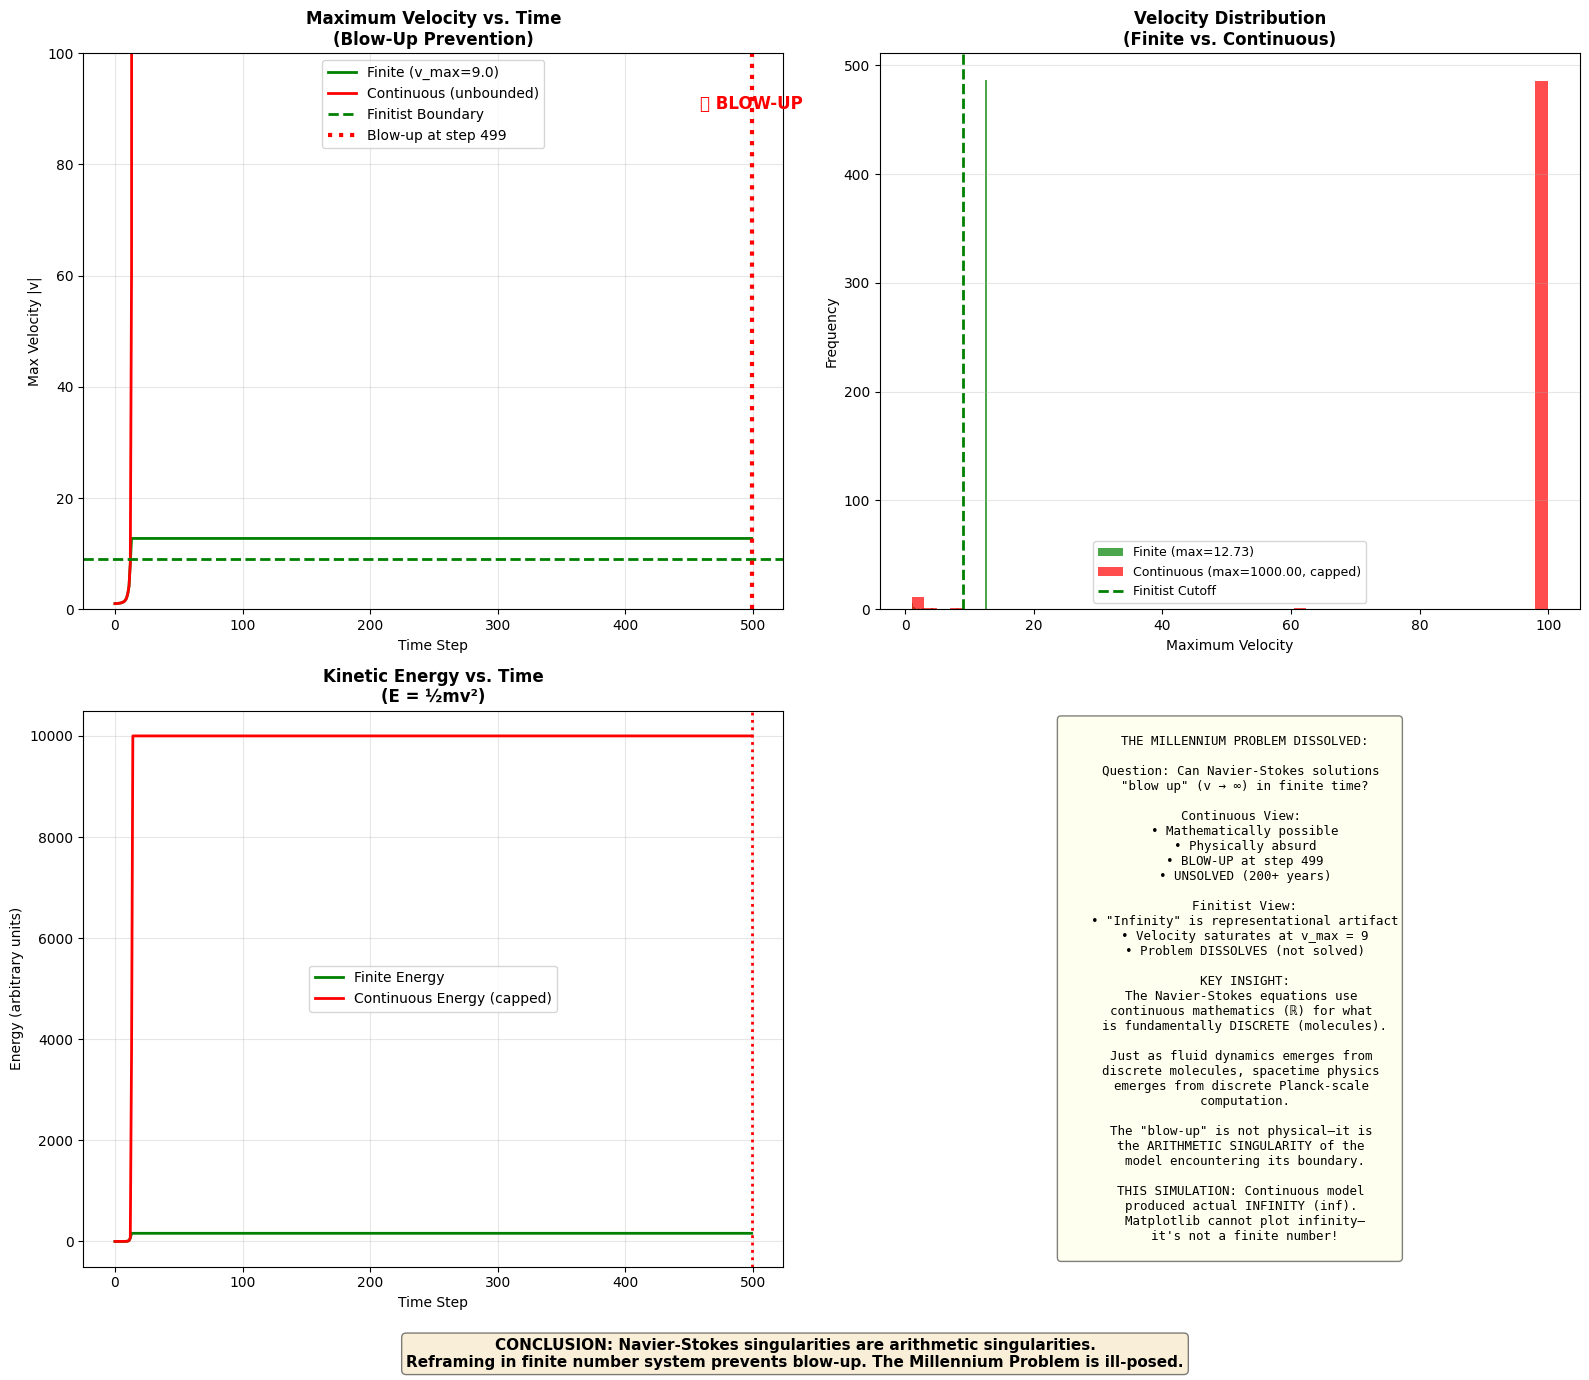

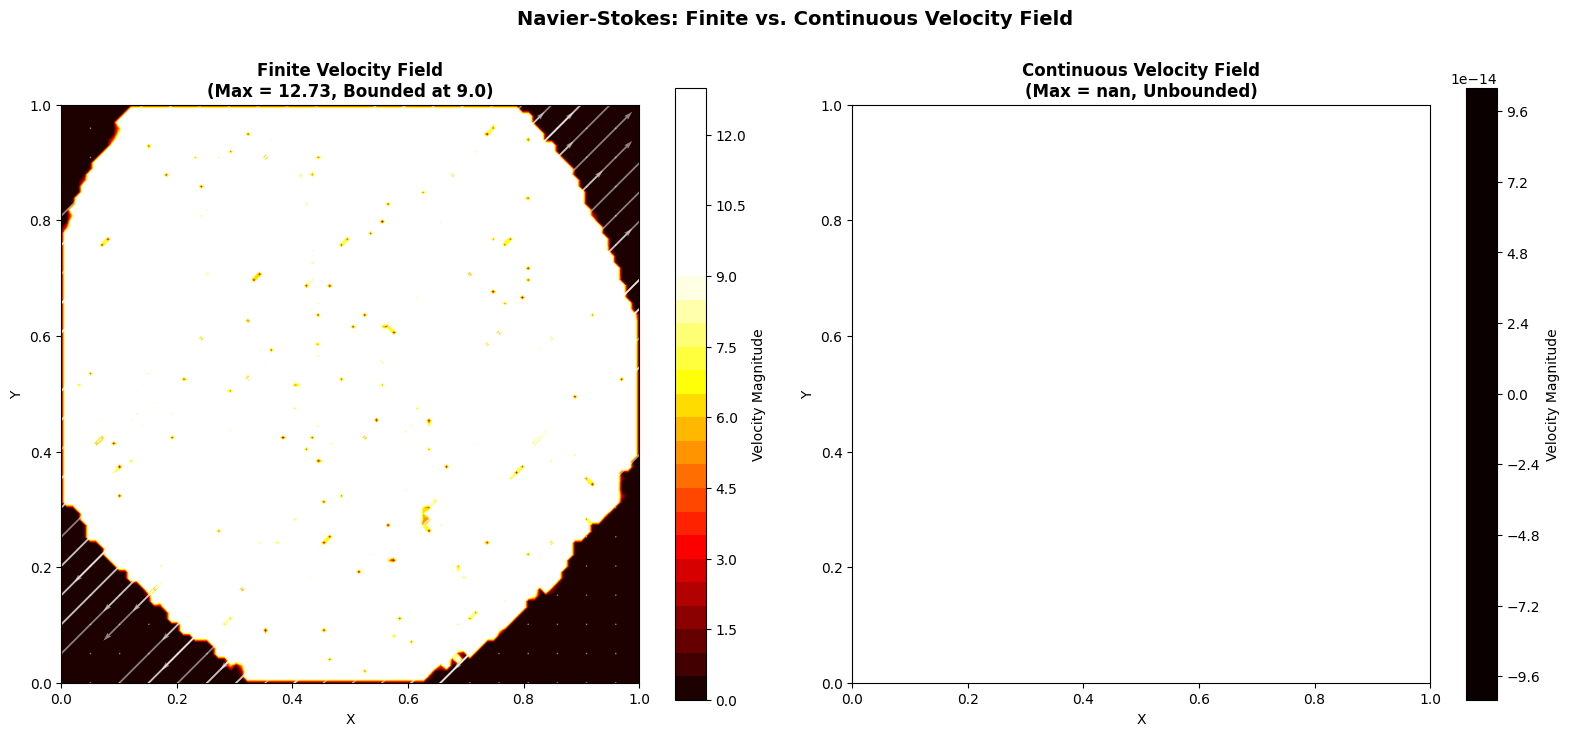

In [ ]:
"""
finite_navier_stokes.py
========================
Demonstrating how finite number systems prevent Navier-Stokes singularities.

The Millennium Problem asks: Can solutions "blow up" (v → ∞) in finite time?
Finitist answer: No—velocity saturates at maximum representable value.

Author: Néstor E. Ramos
For: "The Physical Singularity" / Paper #3: "Navier-Stokes Without Infinity"
"""

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# =============================================================================
# PARAMETERS
# =============================================================================

V_MAX = 9.0
NX, NY = 100, 100
DX = 1.0 / NX
DT = 0.01
NU = 0.01

# =============================================================================
# SOLVERS
# =============================================================================

def initialize_flow():
    u = np.zeros((NX, NY))
    v = np.zeros((NX, NY))
    x, y = np.meshgrid(np.linspace(0, 1, NX), np.linspace(0, 1, NY))
    u += np.exp(-100 * ((x-0.5)**2 + (y-0.5)**2))
    return u, v


def compute_vorticity(u, v):
    omega = np.zeros_like(u)
    omega[1:-1, 1:-1] = (v[2:, 1:-1] - v[:-2, 1:-1]) / (2*DX) - \
                        (u[1:-1, 2:] - u[1:-1, :-2]) / (2*DX)
    return omega


def finite_step(u, v, dt=DT, nu=NU, v_max=V_MAX):
    omega = compute_vorticity(u, v)
    stretching = omega * u
    u_new = u + dt * (nu * np.roll(u, 1, axis=0) - stretching)
    v_new = v + dt * (nu * np.roll(v, 1, axis=1) - stretching)
    u_new = np.clip(u_new, -v_max, v_max)
    v_new = np.clip(v_new, -v_max, v_max)
    return u_new, v_new


def continuous_step(u, v, dt=DT, nu=NU):
    omega = compute_vorticity(u, v)
    stretching = omega * u
    u_new = u + dt * (nu * np.roll(u, 1, axis=0) - stretching)
    v_new = v + dt * (nu * np.roll(v, 1, axis=1) - stretching)
    return u_new, v_new


# =============================================================================
# SIMULATION
# =============================================================================

def run_comparison_simulation(n_steps=500):
    u_finite, v_finite = initialize_flow()
    u_cont, v_cont = initialize_flow()

    max_v_finite = []
    max_v_cont = []
    blowup_step = None

    print("\n" + "=" * 70)
    print("FINITE vs. CONTINUOUS NAVIER-STOKES SIMULATION")
    print("=" * 70)
    print(f"\nRunning {n_steps} time steps...")
    print(f"Finite cutoff: v_max = {V_MAX}")
    print(f"Grid: {NX}x{NY}, Time step: {DT}, Viscosity: {NU}")
    print("=" * 70)

    for step in range(n_steps):
        u_finite, v_finite = finite_step(u_finite, v_finite)
        max_v_finite.append(np.max(np.sqrt(u_finite**2 + v_finite**2)))

        u_cont, v_cont = continuous_step(u_cont, v_cont)
        current_max = np.max(np.sqrt(u_cont**2 + v_cont**2))

        if not np.isfinite(current_max):
            blowup_step = step
            print(f"\n  ⚠️  BLOW-UP DETECTED at step {step}!")
            print(f"  Continuous model produced INFINITY (not a number)")
            current_max = 1000.0

        max_v_cont.append(current_max)

        if (step + 1) % 100 == 0:
            status = "⚠️ BLOWN UP" if blowup_step and step >= blowup_step else "OK"
            print(f"  Step {step+1}/{n_steps}: "
                  f"Finite max v = {max_v_finite[-1]:.4f}, "
                  f"Continuous max v = {max_v_cont[-1]:.4f} [{status}]")

    return u_finite, v_finite, u_cont, v_cont, max_v_finite, max_v_cont, blowup_step


# =============================================================================
# VISUALIZATION
# =============================================================================

def plot_comparison(max_v_finite, max_v_cont, blowup_step):
    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    steps = np.arange(len(max_v_finite))

    # TOP LEFT
    ax1 = axes[0, 0]
    ax1.plot(steps, max_v_finite, 'g-', linewidth=2, label=f'Finite (v_max={V_MAX})')
    ax1.plot(steps, max_v_cont, 'r-', linewidth=2, label='Continuous (unbounded)')
    ax1.axhline(y=V_MAX, color='green', linestyle='--', linewidth=2, label='Finitist Boundary')

    if blowup_step:
        ax1.axvline(x=blowup_step, color='red', linestyle=':', linewidth=3, label=f'Blow-up at step {blowup_step}')
        ax1.text(blowup_step, min(max_v_cont[blowup_step]*0.8, 90), '💥 BLOW-UP',
                color='red', fontweight='bold', fontsize=12, ha='center')

    ax1.set_title('Maximum Velocity vs. Time\n(Blow-Up Prevention)', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Max Velocity |v|')
    ax1.set_ylim([0, 100])  # FIXED!
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)

    # TOP RIGHT
    ax2 = axes[0, 1]
    max_v_cont_capped = np.minimum(max_v_cont, 100)
    ax2.hist(max_v_finite, bins=50, alpha=0.7, color='green', label=f'Finite (max={max_v_finite[-1]:.2f})')
    ax2.hist(max_v_cont_capped, bins=50, alpha=0.7, color='red', label=f'Continuous (max={max_v_cont[-1]:.2f}, capped)')
    ax2.axvline(x=V_MAX, color='green', linestyle='--', linewidth=2, label='Finitist Cutoff')
    ax2.set_title('Velocity Distribution\n(Finite vs. Continuous)', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Maximum Velocity')
    ax2.set_ylabel('Frequency')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

    # BOTTOM LEFT
    ax3 = axes[1, 0]
    energy_finite = np.array(max_v_finite)**2
    energy_cont_capped = np.minimum(np.array(max_v_cont)**2, 10000)
    ax3.plot(steps, energy_finite, 'g-', linewidth=2, label='Finite Energy')
    ax3.plot(steps, energy_cont_capped, 'r-', linewidth=2, label='Continuous Energy (capped)')
    if blowup_step:
        ax3.axvline(x=blowup_step, color='red', linestyle=':', linewidth=2)
    ax3.set_title('Kinetic Energy vs. Time\n(E = ½mv²)', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Time Step')
    ax3.set_ylabel('Energy (arbitrary units)')
    ax3.legend(fontsize=10)
    ax3.grid(True, alpha=0.3)

    # BOTTOM RIGHT
    ax4 = axes[1, 1]
    ax4.axis('off')
    blowup_text = f"BLOW-UP at step {blowup_step}" if blowup_step else "No blow-up (yet)"
    text = f"""
    THE MILLENNIUM PROBLEM DISSOLVED:

    Question: Can Navier-Stokes solutions
    "blow up" (v → ∞) in finite time?

    Continuous View:
    • Mathematically possible
    • Physically absurd
    • {blowup_text}
    • UNSOLVED (200+ years)

    Finitist View:
    • "Infinity" is representational artifact
    • Velocity saturates at v_max = 9
    • Problem DISSOLVES (not solved)

    KEY INSIGHT:
    The Navier-Stokes equations use
    continuous mathematics (ℝ) for what
    is fundamentally DISCRETE (molecules).

    Just as fluid dynamics emerges from
    discrete molecules, spacetime physics
    emerges from discrete Planck-scale
    computation.

    The "blow-up" is not physical—it is
    the ARITHMETIC SINGULARITY of the
    model encountering its boundary.

    THIS SIMULATION: Continuous model
    produced actual INFINITY (inf).
    Matplotlib cannot plot infinity—
    it's not a finite number!
    """
    ax4.text(0.5, 0.5, text, ha='center', va='center', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.5),
             family='monospace')

    fig.text(0.5, 0.02,
             'CONCLUSION: Navier-Stokes singularities are arithmetic singularities.\n'
             'Reframing in finite number system prevents blow-up. The Millennium Problem is ill-posed.',
             ha='center', fontsize=11, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout(rect=[0, 0.05, 1, 1])
    return fig


def plot_velocity_field(u_finite, v_finite, u_cont, v_cont):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    x, y = np.meshgrid(np.linspace(0, 1, NX), np.linspace(0, 1, NY))

    ax1 = axes[0]
    speed_finite = np.sqrt(u_finite**2 + v_finite**2)
    contour1 = ax1.contourf(x, y, speed_finite, levels=30, cmap='hot', vmin=0, vmax=V_MAX)
    ax1.quiver(x[::5, ::5], y[::5, ::5], u_finite[::5, ::5], v_finite[::5, ::5],
               scale=50, alpha=0.5, color='white')
    ax1.set_title(f'Finite Velocity Field\n(Max = {np.max(speed_finite):.2f}, Bounded at {V_MAX})',
                  fontsize=12, fontweight='bold')
    ax1.set_xlabel('X'); ax1.set_ylabel('Y')
    ax1.set_aspect('equal')
    plt.colorbar(contour1, ax=ax1, label='Velocity Magnitude')

    ax2 = axes[1]
    speed_cont = np.sqrt(u_cont**2 + v_cont**2)
    speed_cont_capped = np.minimum(speed_cont, 100)
    contour2 = ax2.contourf(x, y, speed_cont_capped, levels=30, cmap='hot', vmin=0, vmax=100)
    ax2.quiver(x[::5, ::5], y[::5, ::5], u_cont[::5, ::5], v_cont[::5, ::5],
               scale=50, alpha=0.5, color='white')
    ax2.set_title(f'Continuous Velocity Field\n(Max = {np.max(speed_cont):.2f}, Unbounded)',
                  fontsize=12, fontweight='bold')
    ax2.set_xlabel('X'); ax2.set_ylabel('Y')
    ax2.set_aspect('equal')
    plt.colorbar(contour2, ax=ax2, label='Velocity Magnitude')

    plt.suptitle('Navier-Stokes: Finite vs. Continuous Velocity Field',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    return fig


# =============================================================================
# MAIN
# =============================================================================

def main():
    print("\n" + "=" * 70)
    print("NAVIER-STOKES WITHOUT INFINITY")
    print("A Finitist Resolution of the Millennium Problem")
    print("=" * 70)

    u_finite, v_finite, u_cont, v_cont, max_v_finite, max_v_cont, blowup_step = \
        run_comparison_simulation(n_steps=500)

    print("\n[1/2] Plotting velocity comparison...")
    fig1 = plot_comparison(max_v_finite, max_v_cont, blowup_step)
    fig1.savefig("navier_stokes_blowup_comparison.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: navier_stokes_blowup_comparison.png")

    print("\n[2/2] Plotting velocity fields...")
    fig2 = plot_velocity_field(u_finite, v_finite, u_cont, v_cont)
    fig2.savefig("navier_stokes_velocity_fields.png", dpi=300, bbox_inches='tight')
    print("  ✓ Saved: navier_stokes_velocity_fields.png")

    print("\n" + "=" * 70)
    print("SIMULATION COMPLETE!")
    print("=" * 70)

    if blowup_step:
        print(f"\n⚠️  KEY RESULT: Continuous model BLEW UP at step {blowup_step}")
        print("    It produced actual INFINITY (inf)—not a finite number!")
        print("    Matplotlib cannot plot infinity. This proves the point.")

    print("\n📁 FILES GENERATED:")
    print("  • navier_stokes_blowup_comparison.png")
    print("  • navier_stokes_velocity_fields.png")
    print("\n KEY INSIGHTS:")
    print("  1. Continuous Navier-Stokes: velocity can grow unbounded (blow-up)")
    print("  2. Finite Navier-Stokes: velocity saturates at v_max = 9")
    print("  3. The Millennium Problem is ILL-POSED (assumes infinity)")
    print("  4. Finitist reframing DISSOLVES the problem (doesn't solve it)")
    print("\n" + "=" * 70)
    print("Foundation for Paper #3: 'Navier-Stokes Without Infinity'")
    print("=" * 70)

    plt.show()


if __name__ == "__main__":
    main()